# Metoda celor mai apropiați k-vecini


### Importuri necesare

In [53]:
import numpy as np
import matplotlib.pyplot as plt

### Calea catre date

In [54]:
dataPath = "data/"

### Incarcare date train

In [55]:
train_images = np.loadtxt(dataPath + "train_images.txt")
train_labels = np.loadtxt(dataPath + "train_labels.txt",'int8')

<ipython-input-55-b1d6fa58e799>:2: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_labels = np.loadtxt(dataPath + "train_labels.txt",'int8')


In [56]:
print(train_images.shape)
print(train_images.ndim)
print(type(train_images[0,0]))
print(train_images.size)
print(train_images.nbytes)

(1000, 784)
2
<class 'numpy.float64'>
784000
6272000


### Plotare date train

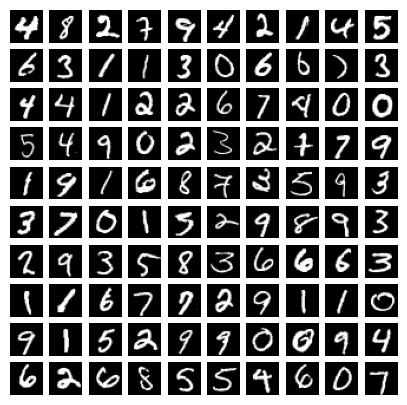

[[4 8 2 7 9 4 2 1 4 5]
 [6 3 1 1 3 0 6 6 7 3]
 [4 4 1 2 2 6 7 4 0 0]
 [5 4 9 0 2 3 2 7 7 9]
 [1 9 1 6 8 7 3 5 9 3]
 [3 7 0 1 3 2 9 8 9 3]
 [2 9 3 5 8 3 6 6 6 3]
 [1 1 6 7 7 2 9 1 1 0]
 [9 1 5 2 9 9 0 0 9 4]
 [6 2 6 8 5 5 4 6 0 7]]


In [48]:
nbImages = 10
plt.figure(figsize=(5,5))
for i in range(nbImages**2):
    plt.subplot(nbImages,nbImages,i+1)
    plt.axis('off')
    plt.imshow(np.reshape(train_images[i,:],(28,28)),cmap = "gray")
plt.show()
labels_nbImages = train_labels[:nbImages**2]
print(np.reshape(labels_nbImages,(nbImages,nbImages)))

### Incarcare date test

In [57]:
test_images = np.loadtxt(dataPath + "test_images.txt")
test_labels = np.loadtxt(dataPath + "test_labels.txt",'int8')

<ipython-input-57-b234e6c87f01>:2: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  test_labels = np.loadtxt(dataPath + "test_labels.txt",'int8')


### Plotare date test

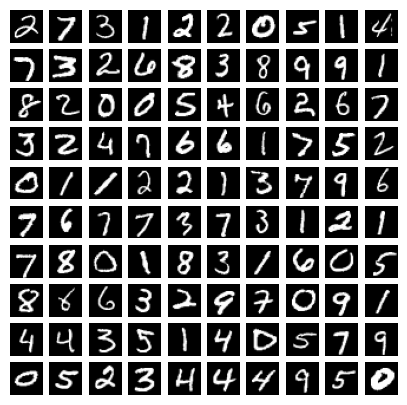

[[2 7 3 1 2 2 0 5 1 4]
 [7 3 2 6 8 3 8 9 9 1]
 [8 2 0 0 5 4 6 2 6 7]
 [3 2 4 7 6 6 1 7 5 2]
 [0 1 1 2 2 1 3 7 9 6]
 [7 6 7 7 3 7 3 1 2 1]
 [7 8 0 1 8 3 1 6 0 5]
 [8 6 6 3 2 9 7 0 9 1]
 [4 4 3 5 1 4 0 5 7 9]
 [0 5 2 3 4 4 4 9 5 0]]


In [58]:
nbImages = 10
plt.figure(figsize=(5,5))
for i in range(nbImages**2):
    plt.subplot(nbImages,nbImages,i+1)
    plt.axis('off')
    plt.imshow(np.reshape(test_images[i,:],(28,28)),cmap = "gray")
plt.show()
labels_nbImages = test_labels[:nbImages**2]
print(np.reshape(labels_nbImages,(nbImages,nbImages)))

1. Considerați primul exemplu din mulțimea de testare (este o imagine cu cifra 2). Determinați și afișați (plotând într-o figură) 
cei mai apropiați k-vecini ai acestui exemplu de testare din mulțimea de antrenare folosind distanța euclidiană (l2). 
Folosiți valorile k = 1, 3, 5, 7. Care va fi eticheta asignată exemplului de testare pentru fiecare din cele 4 cazuri?

test image (784,)
2


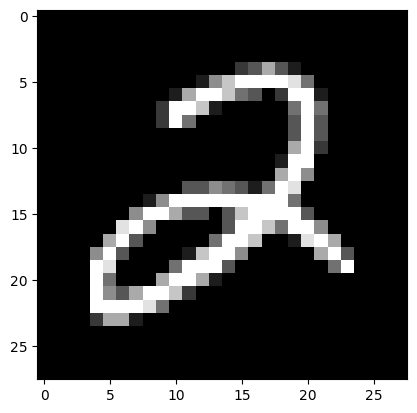

numarul de distante: 1000
primele 10 cele mai mici distante au indecsii [804 395 431 190 745 895  36 794 293 257]
primele 10 cele mai mici distante [1953.71850582 1966.7557042  2036.45451705 2087.20291299 2146.12790858
 2182.07676309 2183.74700916 2188.02170922 2197.46581316 2202.00749318]
Etichetele celor mai mici 1 vecini sunt: [2]
[0 0 1]
Predictia pentru exemplul dat este: 2
Etichetele celor mai mici 3 vecini sunt: [2 2 2]
[0 0 3]
Predictia pentru exemplul dat este: 2
Etichetele celor mai mici 5 vecini sunt: [2 2 2 2 4]
[0 0 4 0 1]
Predictia pentru exemplul dat este: 2
Etichetele celor mai mici 7 vecini sunt: [2 2 2 2 4 2 2]
[0 0 6 0 1]
Predictia pentru exemplul dat este: 2


In [24]:
# Preluam o imagine de test
img = test_images[0, :]
print("test image", img.shape)
print(test_labels[0])

# O afisam
plt.imshow(np.reshape(img, (28, 28)), cmap = "gray")
plt.show()

# Calcul al distantelor => 1000 exemple de antrenare => 1000 distante
distances = np.sqrt(((train_images - img) ** 2).sum(axis=1))
print("numarul de distante:", len(distances))

# Luam indecsii distantelor in ordinea lor crescatoare
indices_of_sorted_distances = distances.argsort()
print("primele 10 cele mai mici distante au indecsii", indices_of_sorted_distances[:10])
print("primele 10 cele mai mici distante", distances[indices_of_sorted_distances[:10]])

# Luam mai multe valori pentru k
ks = [1, 3, 5, 7]
for k in ks:
    # Preluam etichetele celor mai mici k distante
    labels_knn = train_labels[indices_of_sorted_distances[:k]]
    print(f"Etichetele celor mai mici {k} vecini sunt: {labels_knn}")

    # Frecventa etichetelor
    count = np.bincount(labels_knn)
    print(count)

    # Predictia finala
    print(f"Predictia pentru exemplul dat este: {count.argmax()}")

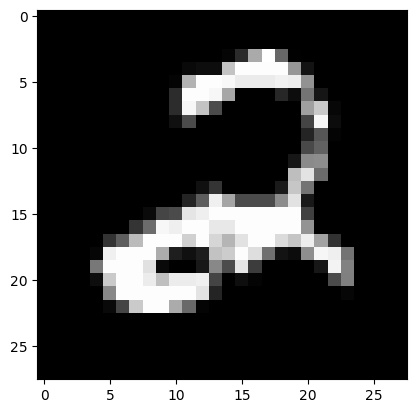

In [20]:
plt.imshow(np.reshape(train_images[431], (28, 28)), cmap = "gray")
plt.show()

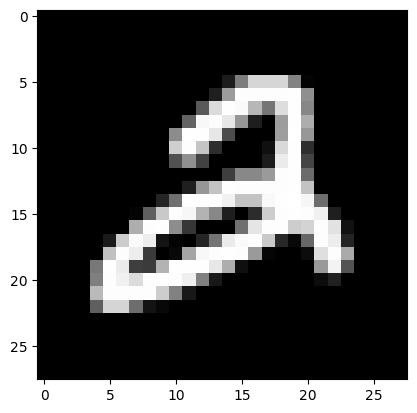

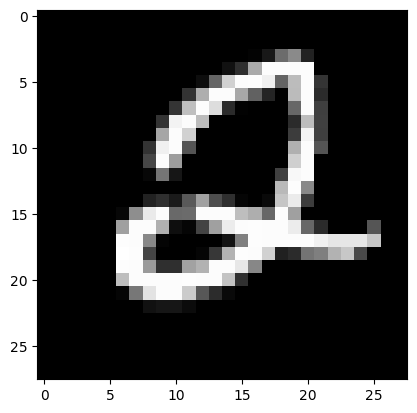

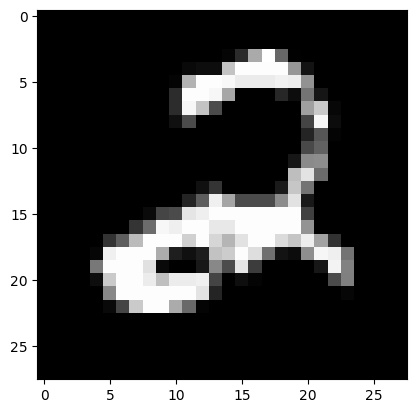

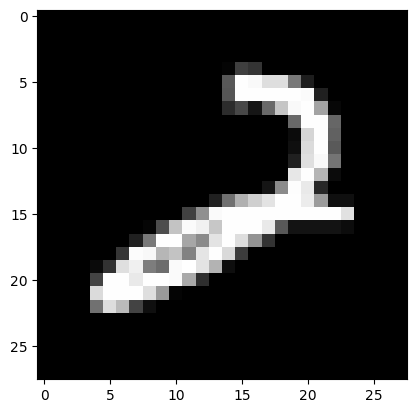

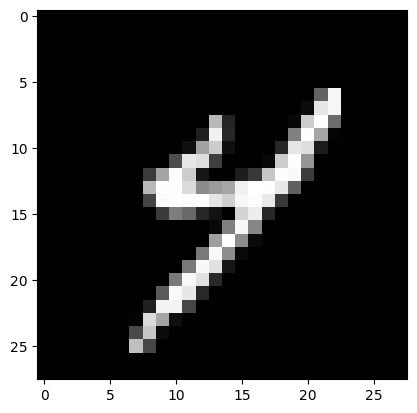

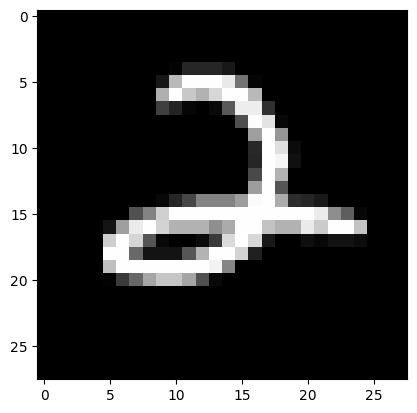

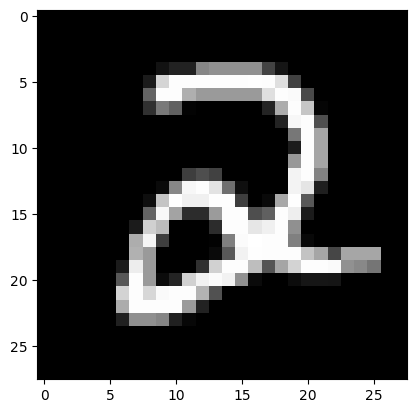

In [26]:
for i in range(7):
    plt.imshow(np.reshape(train_images[indices_of_sorted_distances[i]], (28, 28)), cmap = "gray")
    plt.show()

2. Definiți metoda **classify_image(train_images,train_labels, test_image, num_neighbors = 3, metric = 'l2')** care clasifică imaginea **test_image** folosind exemple etichetate din mulțimea de antrenare (exemplele – train_images, etichetele – train_labels) cu metoda
celor mai apropiați vecini, numărul vecinilor este stabilit de parametru **num_neighbors**, iar distanța poate fi **l1** (distanța Manhattan) sau **l2** (distanța euclidiană), în funcție de parametrul **metric**.

In [28]:
def classify_image(train_images, train_labels, test_image, num_neighbors = 3, metric = 'l2'):
    if metric == 'l2':
        distances = np.sqrt(((train_images - test_image) ** 2).sum(axis=1))
    elif metric == 'l1':
        distances = (abs(train_images - test_image)).sum(axis=1)
    else:
        print(f"Distance metric {metric} is incorrect. Possible values are l1 or l2")
        return -1

    indices_of_sorted_distances = distances.argsort()
    labels_knn = train_labels[indices_of_sorted_distances[:num_neighbors]]
    count = np.bincount(labels_knn)
    return count.argmax()

In [32]:
# Rulam pentru toate datele de test
predicted_labels = np.zeros(len(test_labels))
for i in range(len(test_labels)):
    predicted_labels[i] = classify_image(train_images, train_labels, test_images[i])

print(f"Etichetele GT pentru primele 20 de date de test: {test_labels[:20]}")
print(f"Etichetele PR pentru primele 20 de date de test: {predicted_labels[:20]}")

Etichetele GT pentru primele 20 de date de test: [2 7 3 1 2 2 0 5 1 4 7 3 2 6 8 3 8 9 9 1]
Etichetele PR pentru primele 20 de date de test: [2. 7. 3. 1. 2. 1. 0. 5. 1. 4. 7. 3. 2. 6. 8. 3. 8. 9. 9. 1.]


3. Calculați acuratețea metodei celor mai apropiați vecini pe mulțimea de testare având ca distanță l2 și numărul de vecini 3. Salvați predicțiile în fișierul predictii_3nn_l2_mnist.txt. (Acuratețea pe mulțimea de testare este de 89.8%.)

In [33]:
# Metoda de acuratete
def accuracy(y_true, y_pred):
    count = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            count += 1

    return (count * 100) / len(y_true)

In [34]:
print("Acuratetea modelului KNN pentru k=3 si l2",accuracy(test_labels, predicted_labels))

Acuratetea modelului KNN pentru k=3 si l2 89.8


In [60]:
predicted_labels = np.zeros(len(test_labels))
for i in range(len(test_labels)):
    predicted_labels[i] = classify_image(train_images, train_labels, test_images[i], 3, 'l1')
    
print("Acuratetea modelului KNN pentru k=3 si l1",accuracy(test_labels, predicted_labels))

Acuratetea modelului KNN pentru k=3 si l1 88.4


In [62]:
# predicted_labels = np.zeros(len(test_labels))
# for i in range(len(test_labels)):
#     predicted_labels[i] = classify_image(train_images, train_labels, test_images[i], 3, 'l3')
    
# print("Acuratetea modelului KNN pentru k=3 si l1",accuracy(test_labels, predicted_labels))

In [51]:
# Metoda de confusion matrix
def confusion_matrix(y_true, y_pred):
    C = np.zeros((10,10))
    for i in range(len(y_true)):
        C[int(y_true[i]), int(y_pred[i])] += 1
    return C

In [52]:
print("Matricea de confuzie a modelului KNN pentru k=3 si l2")
C = confusion_matrix(test_labels, predicted_labels)
print(C)

Matricea de confuzie a modelului KNN pentru k=3 si l2
[[51.  0.  0.  0.  0.  1.  1.  0.  0.  0.]
 [ 0. 52.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  6. 47.  1.  0.  0.  1.  2.  0.  0.]
 [ 0.  0.  0. 51.  0.  1.  0.  0.  0.  1.]
 [ 0.  0.  0.  0. 44.  0.  0.  0.  0.  2.]
 [ 2.  1.  1.  6.  0. 40.  1.  0.  0.  1.]
 [ 0.  0.  0.  0.  0.  1. 47.  0.  0.  0.]
 [ 1.  2.  0.  0.  1.  0.  0. 46.  0.  0.]
 [ 1.  0.  2.  2.  1.  1.  1.  1. 36.  1.]
 [ 0.  0.  1.  1.  3.  1.  0.  1.  0. 35.]]


In [42]:
print("Acuratetea modelului folosind confusion matrix", np.diagonal(C).sum() / C.sum())

Acuratetea modelului folosind confusion matrix 0.898
